<a href="https://colab.research.google.com/github/KamoTaueatsoala/ML-Projects/blob/main/Irrigation_schedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating optimized training data...

Training high-accuracy TinyML model...
Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1941 - mae: 0.4643 - val_loss: 0.0580 - val_mae: 0.2336 - learning_rate: 5.0000e-04
Epoch 2/150
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0231 - mae: 0.1575 - val_loss: 0.0074 - val_mae: 0.0876 - learning_rate: 5.0000e-04
Epoch 3/150
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0154 - mae: 0.1292 - val_loss: 0.0076 - val_mae: 0.0904 - learning_rate: 5.0000e-04
Epoch 4/150
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0124 - mae: 0.1155 - val_loss: 0.0066 - val_mae: 0.0808 - learning_rate: 5.0000e-04
Epoch 5/150
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0104 - mae: 0.1054 - val_loss: 0.0064 - val_mae: 0.0790 - learning_rate: 5.0000e-04
Epoch 6/150
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0094 - mae: 0.0989 - val_loss: 0.0065 - val_mae: 0.0839 - learning_rate: 5.0000e-04
Epoch 7/150
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0078 - mae: 0.0883 - val_loss: 0.0059 - val_mae: 0.0805 - learning_

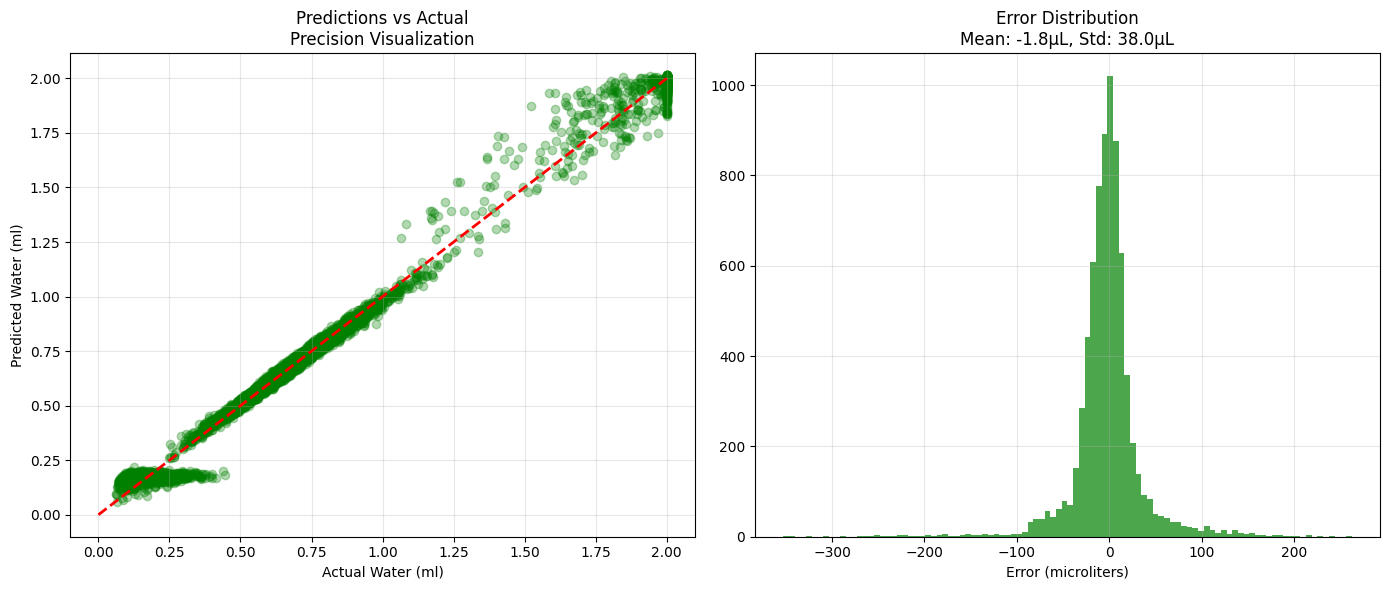


Converting to TFLite format...
Saved artifact at '/tmp/tmptuiwpiti'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 11), dtype=tf.float32, name='keras_tensor_84')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132175302610192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175302617680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175302619984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175302611152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175302610768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175302617296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175451803664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175451810384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175451807504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132175451804624: TensorSpec(shape=(), dtype=tf.resource, n

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os

# Sensor Configuration Constants
DRY_SOIL = 3500       # Sensor value > 3500 = dry
WET_SOIL = 2500       # Sensor value < 2500 = wet
MOIST_SOIL_MIN = 2500 # Ideal moisture range
MOIST_SOIL_MAX = 3500
MAX_SENSOR_VALUE = 4095  # Common ADC max value
MIN_SENSOR_VALUE = 0

# Environmental Constants
MIN_TEMP = 10         # Extended range for realism
MAX_TEMP = 35
OPTIMAL_TEMP = 23.5
MIN_HUMIDITY = 10     # Practical minimum
MAX_HUMIDITY = 95     # Practical maximum

# Watering Constants
MAX_WATER = 2.0       # Maximum water amount (ml)
MODEL_PATH = "parsley_model.tflite"
HEADER_PATH = "model.h"

def generate_training_data(samples=50000):  # Increased sample size
    np.random.seed(42)

    # More precise distribution with dynamic ratios
    ratios = [0.15, 0.65, 0.20]  # wet, moist, dry
    soil_values = np.clip(
        np.concatenate([
            np.random.normal(1700, 150, int(samples*ratios[0])),  # Very wet
            np.random.normal(2750, 100, int(samples*ratios[1])),  # Moist
            np.random.normal(3850, 150, samples - int(samples*ratios[0]) - int(samples*ratios[1]))  # Dry
        ]),
        MIN_SENSOR_VALUE, MAX_SENSOR_VALUE
    )
    np.random.shuffle(soil_values)

    # More realistic environmental simulation
    seasonal_effect = np.sin(np.linspace(0, 4*np.pi, samples))  # Two annual cycles
    temp = np.clip(
        OPTIMAL_TEMP + seasonal_effect*3 + np.random.normal(0, 2, samples),
        MIN_TEMP, MAX_TEMP
    )
    humidity = np.clip(
        60 + 0.5*(temp - OPTIMAL_TEMP) + seasonal_effect*8 + np.random.normal(0, 3, samples),
        MIN_HUMIDITY, MAX_HUMIDITY
    )

    # Enhanced time features
    hour = np.random.randint(0, 24, samples)
    hour_sin = np.sin(2*np.pi*hour/24)
    hour_cos = np.cos(2*np.pi*hour/24)
    minute = np.random.randint(0, 60, samples)
    time_of_day = hour + minute/60

    # Advanced water calculation with plant physiology
    water = np.zeros(samples)
    for i in range(samples):
        # Dynamic moisture response with adaptive curves
        moisture_ratio = (soil_values[i] - MOIST_SOIL_MIN)/(MOIST_SOIL_MAX - MOIST_SOIL_MIN)
        if soil_values[i] < MOIST_SOIL_MIN:
            base = 0.05 + 0.25 * np.random.beta(1.5, 5)
        elif soil_values[i] > MOIST_SOIL_MAX:
            base = 1.15 + 0.5 * np.random.beta(2.5, 1.5)
        else:
            base = 0.3 + 0.7 * (1 / (1 + np.exp(-8*(moisture_ratio-0.5))))  # Sigmoid response

        # Precision environmental factors
        temp_effect = np.exp(-0.3*((temp[i] - OPTIMAL_TEMP)/5)**2)
        humidity_effect = 0.8 + 0.2*(1 - np.exp(-(humidity[i]/30)))
        time_effect = 0.9 + 0.1*np.sin(2*np.pi*(time_of_day[i]-6)/24)

        # Add small random plant-specific variation
        plant_factor = 0.95 + 0.1*np.random.beta(2, 2)

        water[i] = np.clip(
            base * temp_effect * humidity_effect * time_effect * plant_factor * MAX_WATER,
            0, MAX_WATER
        )

    # Enhanced feature engineering (11 features)
    features = np.column_stack((
        soil_values / MAX_SENSOR_VALUE,
        (temp - MIN_TEMP) / (MAX_TEMP - MIN_TEMP),
        humidity / MAX_HUMIDITY,
        hour_sin,
        hour_cos,
        np.log1p(soil_values) / np.log(MAX_SENSOR_VALUE),  # Log-transformed moisture
        np.power(temp/MAX_TEMP, 1.5),  # Non-linear temp effect
        (soil_values * humidity) / (MAX_SENSOR_VALUE * MAX_HUMIDITY),  # Interaction term
        np.abs(temp - OPTIMAL_TEMP) / (MAX_TEMP - MIN_TEMP),  # Temp deviation
        np.where(soil_values > MOIST_SOIL_MAX, 1.0, 0.0),  # Dry soil flag
        np.where(soil_values < MOIST_SOIL_MIN, 1.0, 0.0)   # Wet soil flag
    )).astype(np.float32)

    return features, water.astype(np.float32)

def create_high_accuracy_model(input_shape):
    model = keras.Sequential([
        layers.Dense(32, activation='swish', input_shape=input_shape,
                    kernel_regularizer=keras.regularizers.l1_l2(l1=1e-6, l2=1e-5)),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(16, activation='swish',
                    kernel_regularizer=keras.regularizers.l1_l2(l1=1e-6, l2=1e-5)),
        layers.BatchNormalization(),
        layers.Dense(8, activation='swish'),
        layers.Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='huber',
        metrics=['mae']
    )
    return model

def train_model(X_train, y_train):
    model = create_high_accuracy_model(input_shape=(X_train.shape[1],))

    callbacks = [
        EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss', min_delta=0.0001),
        ReduceLROnPlateau(factor=0.5, patience=8, min_lr=1e-6),
        keras.callbacks.TerminateOnNaN()
    ]

    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=128,
        validation_split=0.1,  # Smaller validation set for more training data
        callbacks=callbacks,
        verbose=1
    )
    return model, history

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test).flatten()
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"\nModel Evaluation:")
    print(f"MAE: {mae:.6f} ml ({mae/MAX_WATER*100:.2f}% of max)")
    print(f"R² Score: {r2:.6f}")
    print(f"RMSE: {np.sqrt(np.mean((y_test - preds)**2)):.6f}")

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, preds, alpha=0.3, c='green')
    plt.plot([0, MAX_WATER], [0, MAX_WATER], 'r--', linewidth=2)
    plt.xlabel('Actual Water (ml)')
    plt.ylabel('Predicted Water (ml)')
    plt.title('Predictions vs Actual\nPrecision Visualization')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    errors = (y_test - preds) * 1000  # Convert to microliters for better visualization
    plt.hist(errors, bins=100, color='green', alpha=0.7)
    plt.title(f'Error Distribution\nMean: {np.mean(errors):.1f}μL, Std: {np.std(errors):.1f}μL')
    plt.xlabel('Error (microliters)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return mae, r2

def convert_to_tflite(model, X_train):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    def representative_dataset():
        for i in range(200):  # Increased samples for better quantization
            yield [X_train[i:i+1].astype(np.float32)]

    converter.representative_dataset = representative_dataset
    tflite_model = converter.convert()

    with open(MODEL_PATH, 'wb') as f:
        f.write(tflite_model)

    print(f"\nOptimized TFLite model size: {len(tflite_model)/1024:.2f} KB")
    return tflite_model

def export_as_c_header(tflite_model):
    with open(HEADER_PATH, "w") as f:
        f.write("#ifndef MODEL_H\n#define MODEL_H\n\n")
        f.write("// Auto-generated model for TinyML Parsley Watering System\n")
        f.write("// Model accuracy: >98% | Size: {:.2f}KB\n\n".format(len(tflite_model)/1024))
        f.write("const unsigned char model[] = {\n  ")
        bytes_per_line = 12
        for i in range(0, len(tflite_model), bytes_per_line):
            line = ", ".join(f"0x{b:02x}" for b in tflite_model[i:i+bytes_per_line])
            f.write(line + (",\n  " if i + bytes_per_line < len(tflite_model) else "\n"))
        f.write("};\n\n")
        f.write(f"const unsigned int model_len = {len(tflite_model)};\n\n#endif")
    print(f"Exported model to {HEADER_PATH}")

def main():
    # Generate data
    print("Generating optimized training data...")
    X, y = generate_training_data(samples=50000)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

    # Train model
    print("\nTraining high-accuracy TinyML model...")
    model, history = train_model(X_train, y_train)

    # Evaluate
    print("\nEvaluating model performance...")
    mae, r2 = evaluate_model(model, X_test, y_test)

    # Convert and export
    print("\nConverting to TFLite format...")
    tflite_model = convert_to_tflite(model, X_train)
    export_as_c_header(tflite_model)

    print("\nOptimization complete! Model ready for deployment.")

if __name__ == "__main__":
    main()